# Notebook 05 — AutoReg

Este notebook implementa el modelo AutoReg para la predicción de la
huella de carbono operacional del sistema eléctrico español con
resolución de 15 minutos.

A diferencia de ARIMA y SARIMA, AutoReg es una regresión lineal directa sobre
un gran número de rezagos, lo que lo hace computacionalmente eficiente
y capaz de capturar dependencias de largo alcance sin el coste
del espacio de estados.

**Features:** rezagos de la serie + sin/cos de la hora del día

**Evaluación:** walk-forward con 12 fits distribuidos por 2024,
ventana expansiva con todo el histórico disponible.

**Horizontes:** 48h (192 pasos) y 72h (288 pasos).

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from dataclasses import dataclass
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.ar_model import AutoReg
import warnings
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8")
%matplotlib inline

BASE_DIR    = Path("/home/ubuntu/TFM")
DATA_DIR    = BASE_DIR / "notebooks/data_processed"
RESULTS_DIR = BASE_DIR / "results"
RESULTS_DIR.mkdir(exist_ok=True)

print("Librerías cargadas OK")

Librerías cargadas OK


## 1. Carga de datos

In [2]:
y_train = pd.read_parquet(DATA_DIR / "train_2022_2023.parquet")["y"].astype(float)
y_val   = pd.read_parquet(DATA_DIR / "val_2024.parquet")["y"].astype(float)
y_test  = pd.read_parquet(DATA_DIR / "test_2025.parquet")["y"].astype(float)

y_train.index = pd.to_datetime(y_train.index)
y_val.index   = pd.to_datetime(y_val.index)
y_test.index  = pd.to_datetime(y_test.index)

print("Train:", y_train.shape, "|", y_train.index.min(), "->", y_train.index.max())
print("Val:  ", y_val.shape,   "|", y_val.index.min(),   "->", y_val.index.max())
print("Test: ", y_test.shape,  "|", y_test.index.min(),  "->", y_test.index.max())

Train: (70080,) | 2022-01-01 00:00:00+00:00 -> 2023-12-31 23:45:00+00:00
Val:   (35136,) | 2024-01-01 00:00:00+00:00 -> 2024-12-31 23:45:00+00:00
Test:  (35040,) | 2025-01-01 00:00:00+00:00 -> 2025-12-31 23:45:00+00:00


## 2. Configuración temporal y métricas

In [3]:
FREQ_MIN        = 15
STEPS_PER_HOUR  = 60 // FREQ_MIN
SEASONAL_PERIOD = 24 * STEPS_PER_HOUR  # 96

HORIZONS = {
    "48h": 48 * STEPS_PER_HOUR,  # 192 pasos
    "72h": 72 * STEPS_PER_HOUR,  # 288 pasos
}

@dataclass
class WFConfig:
    step: int
    min_history: int
    max_fits: int

def compute_metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {"MAE": mae, "RMSE": rmse}

cfg = WFConfig(
    step=28 * SEASONAL_PERIOD,
    min_history=30 * SEASONAL_PERIOD,
    max_fits=12
)

print("Periodo estacional:", SEASONAL_PERIOD)
print("Horizontes:", HORIZONS)
print(f"cfg: step={cfg.step} pasos = 28 días, max_fits={cfg.max_fits}")

Periodo estacional: 96
Horizontes: {'48h': 192, '72h': 288}
cfg: step=2688 pasos = 28 días, max_fits=12


## 3. Features cíclicas — sin/cos de la hora

Codificamos la hora del día como seno y coseno del slot de 15 minutos.

La codificación cíclica garantiza que horas cercanas en el tiempo
sean cercanas en el espacio de features — por ejemplo 23:45 y 00:00
tienen representaciones similares, algo que una variable lineal
no capturaría.

In [4]:
def make_cyclic_features(index, interval_minutes=15):
    slots_per_day = int(24 * 60 / interval_minutes)
    slot = (index.hour * 60 + index.minute) // interval_minutes
    sin  = np.sin(2 * np.pi * slot / slots_per_day)
    cos  = np.cos(2 * np.pi * slot / slots_per_day)
    return pd.DataFrame({"slot_sin": sin, "slot_cos": cos}, index=index)

exog_train = make_cyclic_features(y_train.index)
exog_val   = make_cyclic_features(y_val.index)
exog_test  = make_cyclic_features(y_test.index)

print("Exog train:", exog_train.shape)
print("Exog val:  ", exog_val.shape)
print(exog_train.head())

Exog train: (70080, 2)
Exog val:   (35136, 2)
                           slot_sin  slot_cos
timestamp                                    
2022-01-01 00:00:00+00:00  0.000000  1.000000
2022-01-01 00:15:00+00:00  0.065403  0.997859
2022-01-01 00:30:00+00:00  0.130526  0.991445
2022-01-01 00:45:00+00:00  0.195090  0.980785
2022-01-01 01:00:00+00:00  0.258819  0.965926


## 4. Función de predicción

La función recibe la serie de entrenamiento, las features cíclicas
asociadas y las features futuras para el horizonte a predecir.

Internamente entrena un modelo AutoReg con el número de lags
especificado y predice h pasos hacia adelante usando dynamic=False,
lo que significa que en cada paso usa los valores reales observados
como input en lugar de las predicciones anteriores.

In [5]:
def forecast_autoreg(train, train_exog, future_exog, h, lags=384):
    model     = AutoReg(train.values, lags=lags, trend="n", exog=train_exog)
    model_fit = model.fit()
    n         = len(train)
    preds     = model_fit.predict(
        start=n,
        end=n + h - 1,
        dynamic=False,
        exog_oos=future_exog
    )
    return preds

print("forecast_autoreg definida OK")

forecast_autoreg definida OK


## 5. Walk-forward

In [6]:
def walk_forward_splits(series, horizons, cfg):
    n      = len(series)
    max_h  = max(horizons.values())
    points = list(range(cfg.min_history, n - max_h, cfg.step))
    points = points[:cfg.max_fits]
    for t0 in points:
        train_part = series.iloc[:t0]
        tests = {k: series.iloc[t0:t0 + h] for k, h in horizons.items()}
        yield train_part, tests

def summarize(df, model_name):
    out = (
        df.groupby("horizon")[["MAE", "RMSE"]]
        .mean()
        .reset_index()
    )
    out.insert(0, "model", model_name)
    return out

def evaluate_autoreg(y_train, y_val, exog_train, exog_val,
                     horizons, cfg, lags=384, verbose=True):
    rows        = []
    preds_store = []
    y_full    = pd.concat([y_train, y_val]).sort_index()
    exog_full = pd.concat([exog_train, exog_val]).sort_index()
    n_train   = len(y_train)
    splits    = list(walk_forward_splits(y_val, horizons, cfg))
    total     = len(splits)

    for i, (train_part, tests) in enumerate(splits, 1):
        if verbose:
            print(f"Fit {i}/{total}")
        cutoff_idx   = n_train + len(train_part)
        cutoff_time  = y_full.index[cutoff_idx - 1]
        train_window = y_full.iloc[:cutoff_idx]
        train_exog_w = exog_full.iloc[:cutoff_idx]

        fit_preds = {"cutoff_time": cutoff_time, "train_window": train_window}
        for name, test in tests.items():
            h           = len(test)
            future_exog = exog_full.iloc[cutoff_idx:cutoff_idx + h]
            pred        = forecast_autoreg(train_window, train_exog_w, future_exog, h, lags)
            m           = compute_metrics(test.values, pred)
            rows.append({"horizon": name, "MAE": m["MAE"], "RMSE": m["RMSE"]})
            fit_preds[name] = {"pred": pred, "test": test}
        preds_store.append(fit_preds)

    return pd.DataFrame(rows), preds_store

print("Walk-forward definido OK")

Walk-forward definido OK


## 6. Selección del número de lags óptimo

Se evalúa el modelo con distintos valores de lags para encontrar
el que minimiza el MAE en el conjunto de validación.

El número de lags determina cuántos pasos atrás mira el modelo
para hacer la predicción:
- lags=96  -> 1 día de memoria
- lags=192 -> 2 días de memoria
- lags=384 -> 4 días de memoria 
- lags=576 -> 6 días de memoria
- lags=768 -> 8 días de memoria

In [9]:
resultados_lags = []

for lags in [96, 192, 384, 576, 768]:
    print(f"\nProbando lags={lags}...")
    df_res, _ = evaluate_autoreg(
        y_train, y_val,
        exog_train, exog_val,
        HORIZONS, cfg,
        lags=lags,
        verbose=False
    )
    summary = summarize(df_res, f"AutoReg({lags})")
    resultados_lags.append(summary)
    print(summary)

comparacion_lags = pd.concat(resultados_lags, ignore_index=True)
print("\n--- COMPARACIÓN FINAL ---")
print(comparacion_lags)
comparacion_lags.to_csv(RESULTS_DIR / "autoreg_lags_search.csv", index=False)


Probando lags=96...
         model horizon        MAE       RMSE
0  AutoReg(96)     48h  16.628421  21.093653
1  AutoReg(96)     72h  19.137255  23.799721

Probando lags=192...
          model horizon        MAE       RMSE
0  AutoReg(192)     48h  14.886442  19.449171
1  AutoReg(192)     72h  17.461753  22.171346

Probando lags=384...
          model horizon        MAE       RMSE
0  AutoReg(384)     48h  13.924354  18.417823
1  AutoReg(384)     72h  16.478205  21.245241

Probando lags=576...
          model horizon        MAE       RMSE
0  AutoReg(576)     48h  13.693741  17.990508
1  AutoReg(576)     72h  16.212660  20.953722

Probando lags=768...
          model horizon        MAE       RMSE
0  AutoReg(768)     48h  13.678282  17.888497
1  AutoReg(768)     72h  16.418967  21.155829

--- COMPARACIÓN FINAL ---
          model horizon        MAE       RMSE
0   AutoReg(96)     48h  16.628421  21.093653
1   AutoReg(96)     72h  19.137255  23.799721
2  AutoReg(192)     48h  14.886442  19.

## 7. Análisis de resultados — selección de lags

lags=576 minimiza el MAE en 72h y es prácticamente igual a lags=768
en 48h. A partir de 576 la mejora es marginal y no justifica el
coste computacional adicional.

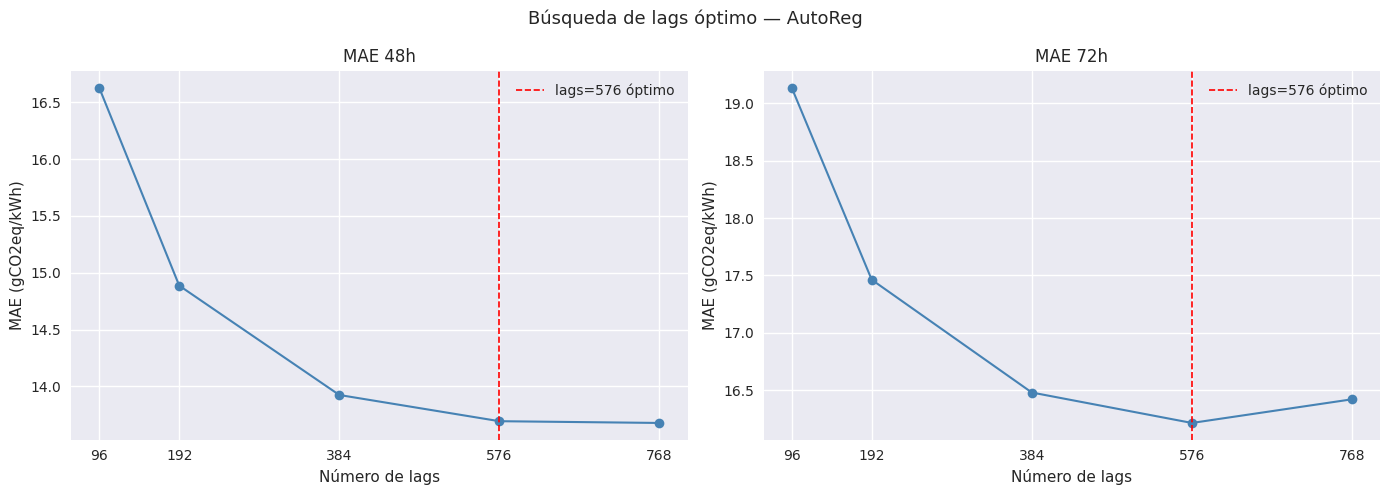

Lags óptimo seleccionado: 576


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Búsqueda de lags óptimo — AutoReg", fontsize=13)

lags_vals = [96, 192, 384, 576, 768]

for ax, horizon in zip(axes, ["48h", "72h"]):
    mae_vals = comparacion_lags[comparacion_lags["horizon"] == horizon]["MAE"].values
    ax.plot(lags_vals, mae_vals, marker="o", color="steelblue", linewidth=1.5)
    ax.axvline(x=576, color="red", linestyle="--", linewidth=1.2, label="lags=576 óptimo")
    ax.set_title(f"MAE {horizon}")
    ax.set_xlabel("Número de lags")
    ax.set_ylabel("MAE (gCO2eq/kWh)")
    ax.set_xticks(lags_vals)
    ax.legend()

plt.tight_layout()
plt.savefig("/home/ubuntu/TFM/figures/autoreg_lags_search.png", dpi=150, bbox_inches="tight")
plt.show()

# Lags óptimo
LAGS_OPT = 576
print(f"Lags óptimo seleccionado: {LAGS_OPT}")

## 8. Modelo final — AutoReg(576)

Se entrena el modelo final con lags=576 y se evalúa con el
walk-forward completo de 12 fits distribuidos por 2024.

In [11]:
print("Entrenando AutoReg(576)...")
autoreg_val, preds_store = evaluate_autoreg(
    y_train, y_val,
    exog_train, exog_val,
    HORIZONS, cfg,
    lags=LAGS_OPT,
    verbose=True
)

autoreg_summary = summarize(autoreg_val, f"AutoReg({LAGS_OPT})")
autoreg_summary.to_csv(RESULTS_DIR / "autoreg_summary.csv", index=False)
print(autoreg_summary)

Entrenando AutoReg(576)...
Fit 1/12
Fit 2/12
Fit 3/12
Fit 4/12
Fit 5/12
Fit 6/12
Fit 7/12
Fit 8/12
Fit 9/12
Fit 10/12
Fit 11/12
Fit 12/12
          model horizon        MAE       RMSE
0  AutoReg(576)     48h  13.693741  17.990508
1  AutoReg(576)     72h  16.212660  20.953722


## 9. Visualización — predicciones vs real

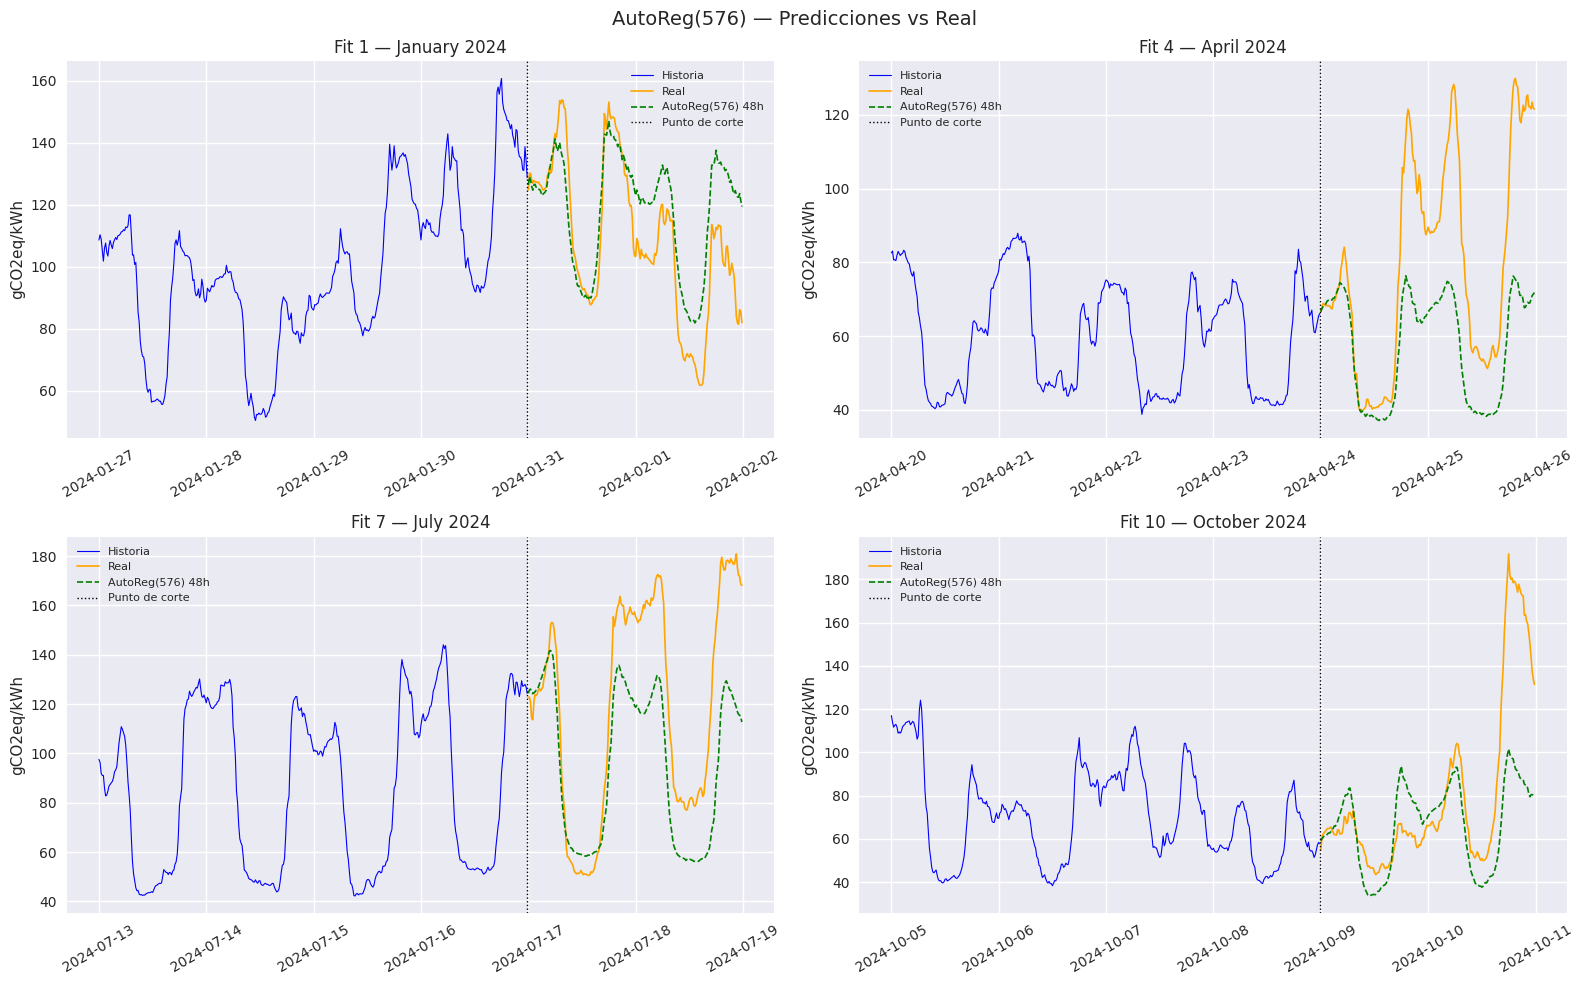

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(f"AutoReg({LAGS_OPT}) — Predicciones vs Real", fontsize=14)

for idx, split_idx in enumerate([0, 3, 6, 9]):
    ax = axes[idx // 2][idx % 2]
    fit         = preds_store[split_idx]
    cutoff_time = fit["cutoff_time"]
    train_w     = fit["train_window"]
    test_48     = fit["48h"]["test"]
    pred_48     = fit["48h"]["pred"]

    history = train_w.iloc[-4 * SEASONAL_PERIOD:]
    ax.plot(history.index, history.values,
            color="blue", label="Historia", linewidth=0.8)
    ax.plot(test_48.index, test_48.values,
            color="orange", label="Real", linewidth=1.2)
    ax.plot(test_48.index, pred_48,
            color="green", linestyle="--", label=f"AutoReg({LAGS_OPT}) 48h", linewidth=1.2)
    ax.axvline(x=cutoff_time, color="black", linestyle=":",
               linewidth=1.0, label="Punto de corte")
    ax.set_title(f"Fit {split_idx+1} — {cutoff_time.strftime('%B %Y')}")
    ax.set_ylabel("gCO2eq/kWh")
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(f"/home/ubuntu/TFM/figures/autoreg_predicciones.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Comparación de resultados

In [15]:
naive_arima      = pd.read_csv(RESULTS_DIR / "comparacion_naive_arima.csv")
sarima_summary   = pd.read_csv(RESULTS_DIR / "sarima_summary.csv")
autoreg_summary  = pd.read_csv(RESULTS_DIR / "autoreg_summary.csv")

comparacion_final = pd.concat([
    naive_arima,
    sarima_summary,
    autoreg_summary
], ignore_index=True)

comparacion_final["MAE"]  = comparacion_final["MAE"].round(3)
comparacion_final["RMSE"] = comparacion_final["RMSE"].round(3)

tabla_final = comparacion_final.pivot_table(
    index="model",
    columns="horizon",
    values=["MAE", "RMSE"]
).round(3)

tabla_final = tabla_final.sort_values(("MAE", "48h"))

print(tabla_final)
comparacion_final.to_csv(RESULTS_DIR / "comparacion_todos_estadisticos.csv", index=False)

                                  MAE            RMSE        
horizon                           48h     72h     48h     72h
model                                                        
AutoReg(576)                   13.694  16.213  17.991  20.954
Naive_seasonal                 18.302  19.662  22.742  24.617
SARIMA(1, 1, 0)x(1, 0, 0, 96)  25.201  29.039  31.023  35.113
ARIMA(5,1,0)                   27.155  28.061  33.796  34.877
Naive_last                     27.914  29.777  33.984  35.971


## 11. Interpretación de resultados — todos los modelos estadísticos

| Modelo | MAE 48h | MAE 72h |
|--------|---------|---------|
| AutoReg(576) | 13.69 | 16.21 |
| Naive_seasonal | 18.30 | 19.66 |
| SARIMA(1,1,0)(1,0,0)[96] | 25.20 | 29.04 |
| ARIMA(5,1,0) | 27.16 | 28.06 |
| Naive_last | 27.91 | 29.78 |

AutoReg(576) es el mejor modelo estadístico evaluado, superando
al Naive_seasonal en un **25% a 48h** y un **18% a 72h**.

La clave de este resultado son los 576 rezagos — 6 días de memoria
— que permiten al modelo capturar el patrón diario completo y las
dependencias de largo alcance de la serie, algo que ARIMA y SARIMA
no pueden hacer por sus limitaciones computacionales.

### Siguiente paso — variables exógenas

AutoReg en su configuración actual solo usa información pasada de
la propia serie (rezagos) y las features cíclicas de la hora del día
(sin/cos). Sin embargo la huella de carbono del sistema eléctrico
español está influenciada por la generación solar fotovoltaica,
que a su vez depende de la irradiación solar y la posición del sol.

En el notebook siguiente incorporamoas estas variables exógenas
de forma progresiva para analizar su impacto en el error de
predicción:

- **GHI** -> irradiación global horizontal (W/m²)
- **solar_elevation** -> altura del sol sobre el horizonte (°)
- **solar_azimuth** -> posición horizontal del sol (°)

Estas variables se calculan a partir del perfil climatológico medio
2005-2023 obtenido de PVGIS ERA5, proporcionando una estimación
robusta y reproducible de las condiciones solares esperadas para
cada instante del año.